# Angle Reindexing

As a legacy from wradlib we have complex code for angle reindexing in xradar's codebase.

## High precision angle coordinates

As radar angle coordinates (`azimuth` or `elevation`) are measured constantly by different techniques of detection of the antenna pointing direction the values in the data files are mostly floating point numbers. In many cases these floating point numbers are not rounded to a certain decimal but keep the full possible range of the used dtype.

Problems of that:

- 1D angle coordinate arrays yield no equidistant vector.
- 1D angle coordinate arrays are not equivalent for different timesteps but same scan setup

## Missing rays, duplicate or additional rays

Sometimes rays (even sectors) are missing from the dataset, sometimes there are duplicate rays. Another problem with radar data are additional rays, which I call "antenna hickup" (two rays measured with within one resolution interval).

## What is angle reindexing?

Angle reindexing takes care of these problems by trying to determine the wanted layout from the radar metadata and the angle coordinates. With that newly created angle coordinate xarray machinery is used to reindex the radar moment data to that by nearest neighbor lookup (up to a tolerance). Missing rays will be filled with NaN.

## Why should it be used?

For most operations this is not a real problem. It will turn into a problem, if you want to stack your xarray.Dataset radar data on a third dimension (eg. `time`, by using `open_mfdataset`). Then all coordinates need alignment to keep things simple and manageable (eg. `azimuth=[0.5, 1.5, 2.5,..., 359.5]`)

## How should we treat it?

Currently the reindexing code relies on some internals which make things a bit hard to maintain. My suggestion would be to disentangle the reindexing code from the internals but feed the needed values as parameters. Then every reader can call this per activated `reindex_angle` kwarg.

## Angle Reindexing Example

In [1]:
import matplotlib.pyplot as plt
import xarray as xr
from open_radar_data import DATASETS

import xradar as xd

In [2]:
filename = DATASETS.fetch("DWD-Vol-2_99999_20180601054047_00.h5")

In [3]:
def fix_angle(ds):
    angle_dict = xd.util.extract_angle_parameters(ds)
    display(angle_dict)
    start_ang = angle_dict["start_angle"]
    stop_ang = angle_dict["stop_angle"]
    angle_res = angle_dict["angle_res"]
    direction = angle_dict["direction"]

    # first find exact duplicates and remove
    ds = xd.util.remove_duplicate_rays(ds)

    # second reindex according to retrieved parameters
    ds = xd.util.reindex_angle(
        ds, start_ang, stop_ang, angle_res, direction, method="nearest"
    )

    return ds

### Read example data with one additional ray

In [4]:
ds0 = xr.open_dataset(filename, group="sweep_7", engine="gamic", first_dim="auto")
display(ds0.load())

C:\Users\egoud\.venvs\wradlib\Lib\site-packages\xarray\backends\plugins.py:110: RuntimeWarning: Engine 'radolan' loading failed:
module 'wradlib.georef.raster' has no attribute 'read_gdal_values'
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)


<xarray.Dataset> Size: 17MB
Dimensions:            (azimuth: 361, range: 1000)
Coordinates:
  * azimuth            (azimuth) float64 3kB 0.5246 1.538 2.521 ... 358.5 359.5
    elevation          (azimuth) float64 3kB 3.098 3.098 3.098 ... 3.098 3.098
    time               (azimuth) datetime64[ns] 3kB 2018-06-01T05:42:51.84200...
  * range              (range) float32 4kB 75.0 225.0 ... 1.498e+05 1.499e+05
    longitude          float64 8B 6.457
    latitude           float64 8B 50.93
    altitude           float64 8B 310.0
Data variables: (12/18)
    DBZH               (azimuth, range) float32 1MB 14.68 17.69 ... nan nan
    DBZV               (azimuth, range) float32 1MB 12.17 16.69 18.2 ... nan nan
    KDP                (azimuth, range) float32 1MB -15.0 -15.0 ... 0.0 0.0
    RHOHV              (azimuth, range) float32 1MB 0.9165 0.9463 ... 0.1558
    DBTH               (azimuth, range) float32 1MB 14.68 17.69 ... 7.656 nan
    DBTV               (azimuth, range) float32 1MB 12.17 16.69 18.2 ... nan nan
    ...                 ...
    sweep_mode         <U20 80B 'azimuth_surveillance'
    sweep_number       int64 8B 7
    prt_mode           <U7 28B 'not_set'
    follow_mode        <U7 28B 'not_set'
    sweep_fixed_angle  float64 8B 3.1
    nyquist_velocity   float64 8B 7.231
Attributes:
    source:         gamic
    ant_gain_h:     43
    ant_gain_v:     43
    noise_power_h:  -3.8298
    noise_power_v:  -3.5802
    rx_loss_h:      3
    rx_loss_v:      3

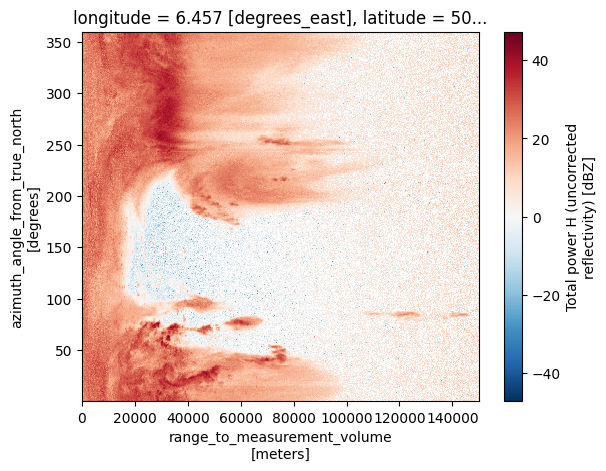

In [5]:
ds0.DBTH.plot()

### Prepare sweep with several sections removed

In [6]:
ds_in = xr.concat(
    [
        ds0.isel(azimuth=slice(0, 100)),
        ds0.isel(azimuth=slice(150, 200)),
        ds0.isel(azimuth=slice(243, 300)),
        ds0.isel(azimuth=slice(330, 361)),
    ],
    "azimuth",
    data_vars="minimal",
)
display(ds_in)

<xarray.Dataset> Size: 11MB
Dimensions:            (azimuth: 238, range: 1000)
Coordinates:
  * azimuth            (azimuth) float64 2kB 0.5246 1.538 2.521 ... 358.5 359.5
    elevation          (azimuth) float64 2kB 3.098 3.098 3.098 ... 3.098 3.098
    time               (azimuth) datetime64[ns] 2kB 2018-06-01T05:42:51.84200...
  * range              (range) float32 4kB 75.0 225.0 ... 1.498e+05 1.499e+05
    longitude          float64 8B 6.457
    latitude           float64 8B 50.93
    altitude           float64 8B 310.0
Data variables: (12/18)
    DBZH               (azimuth, range) float32 952kB 14.68 17.69 ... nan nan
    DBZV               (azimuth, range) float32 952kB 12.17 16.69 ... nan nan
    KDP                (azimuth, range) float32 952kB -15.0 -15.0 ... 0.0 0.0
    RHOHV              (azimuth, range) float32 952kB 0.9165 0.9463 ... 0.1558
    DBTH               (azimuth, range) float32 952kB 14.68 17.69 ... 7.656 nan
    DBTV               (azimuth, range) float32 952kB 12.17 16.69 ... nan nan
    ...                 ...
    sweep_mode         <U20 80B 'azimuth_surveillance'
    sweep_number       int64 8B 7
    prt_mode           <U7 28B 'not_set'
    follow_mode        <U7 28B 'not_set'
    sweep_fixed_angle  float64 8B 3.1
    nyquist_velocity   float64 8B 7.231
Attributes:
    source:         gamic
    ant_gain_h:     43
    ant_gain_v:     43
    noise_power_h:  -3.8298
    noise_power_v:  -3.5802
    rx_loss_h:      3
    rx_loss_v:      3

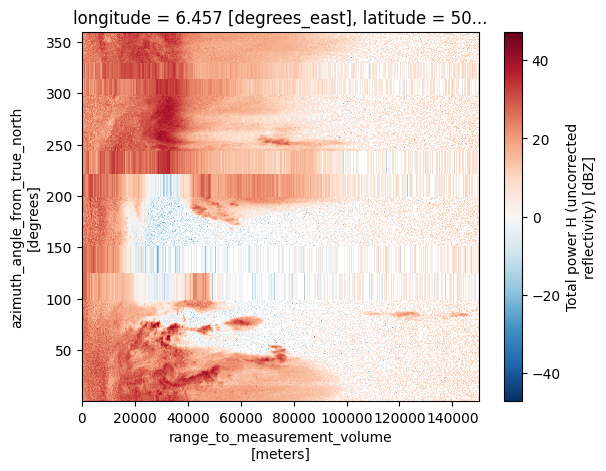

In [7]:
ds_in.DBTH.plot()

### Reindex angle

First output is the extracted angle/time dictionary.

In [8]:
ds_out = fix_angle(ds_in)
display(ds_out)

{'first_angle': 'azimuth',
 'second_angle': 'elevation',
 'min_angle': array(0.52459717),
 'max_angle': array(359.5111084),
 'min_time': np.datetime64('2018-06-01T05:42:44.042000000'),
 'max_time': np.datetime64('2018-06-01T05:43:08.042000000'),
 'angles_are_unique': False,
 'times_are_unique': True,
 'a1gate_idx': array(150),
 'a1gate_val': array(243.52020264),
 'uniform_angle_spacing': False,
 'ascending': array(True),
 'direction': 1,
 'angle_res': array(1.),
 'start_angle': 0,
 'stop_angle': 360,
 'expected_angle_span': 360,
 'missing_rays': array(True),
 'excess_rays': array(False),
 'expected_number_rays': 360}

<xarray.Dataset> Size: 17MB
Dimensions:            (azimuth: 360, range: 1000)
Coordinates:
  * azimuth            (azimuth) float64 3kB 0.5 1.5 2.5 ... 357.5 358.5 359.5
  * range              (range) float32 4kB 75.0 225.0 ... 1.498e+05 1.499e+05
    elevation          (azimuth) float64 3kB 3.098 3.098 3.098 ... 3.098 3.098
    time               (azimuth) datetime64[ns] 3kB 2018-06-01T05:42:51.84200...
    longitude          float64 8B 6.457
    latitude           float64 8B 50.93
    altitude           float64 8B 310.0
Data variables: (12/18)
    DBZH               (azimuth, range) float32 1MB 14.68 17.69 ... nan nan
    DBZV               (azimuth, range) float32 1MB 12.17 16.69 18.2 ... nan nan
    KDP                (azimuth, range) float32 1MB -15.0 -15.0 ... 0.0 0.0
    RHOHV              (azimuth, range) float32 1MB 0.9165 0.9463 ... 0.1558
    DBTH               (azimuth, range) float32 1MB 14.68 17.69 ... 7.656 nan
    DBTV               (azimuth, range) float32 1MB 12.17 16.69 18.2 ... nan nan
    ...                 ...
    sweep_mode         <U20 80B 'azimuth_surveillance'
    sweep_number       int64 8B 7
    prt_mode           <U7 28B 'not_set'
    follow_mode        <U7 28B 'not_set'
    sweep_fixed_angle  float64 8B 3.1
    nyquist_velocity   float64 8B 7.231
Attributes:
    source:         gamic
    ant_gain_h:     43
    ant_gain_v:     43
    noise_power_h:  -3.8298
    noise_power_v:  -3.5802
    rx_loss_h:      3
    rx_loss_v:      3

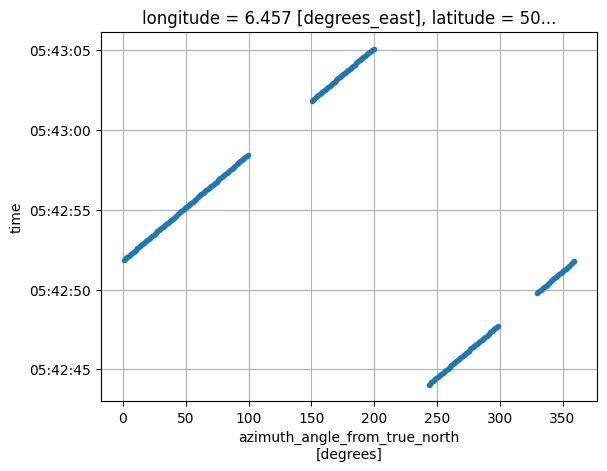

In [9]:
ds_out.time.plot(marker=".")
plt.gca().grid()

We can observe that the dataset is aligned to it's expected number of rays.

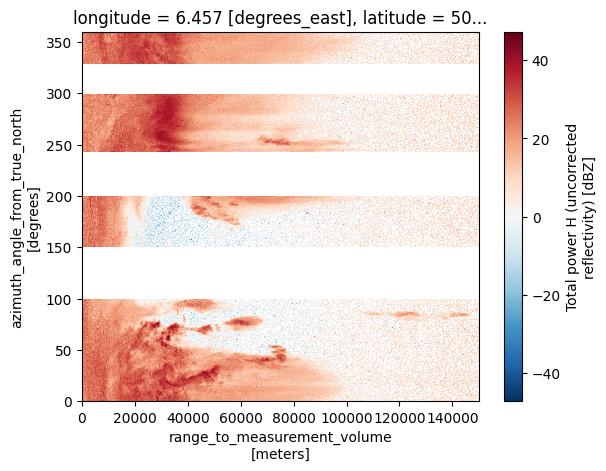

In [10]:
ds_out.DBTH.plot()

### Fix timestamps

As reindexing instantiates the variables/coordinates added rays with `NaN`/`NaT` we need to take care of the coordinates.
The second angle (`elevation` in this case is already treated while reindexing by inserting it's median value, the time coordinate needs special handling.

In [11]:
ds_out2 = ds_out.copy(deep=True)
ds_out2 = ds_out2.pipe(xd.util.ipol_time)

C:\Users\egoud\xradar\xradar\util.py:462: UserWarning: Rays might miss on beginning and/or end of sweep. `a1gate` information is needed to fully recover. We'll assume sweep start at first valid ray.
  warnings.warn(


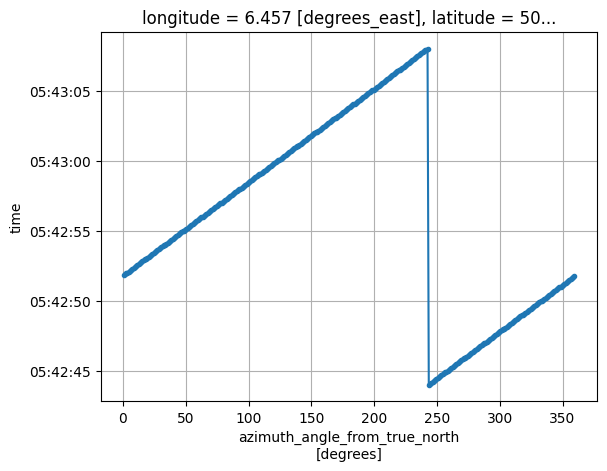

In [12]:
ds_out2.time.plot(marker=".")
plt.gca().grid()

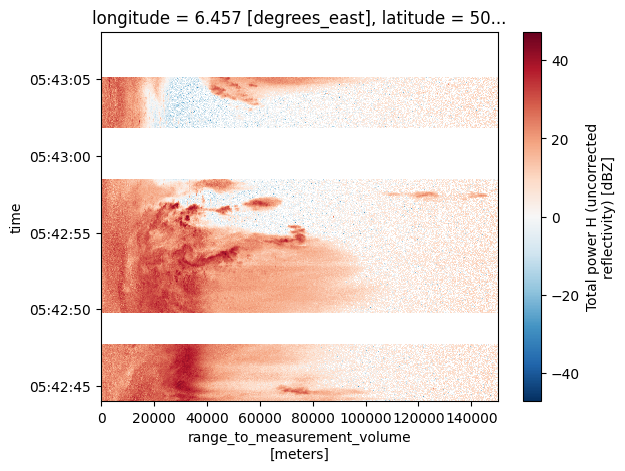

In [13]:
ds_out2.DBTH.sortby("time").plot(y="time")